In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from imblearn.over_sampling import SMOTE

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
# Assuming TB.csv is in the working directory
df = pd.read_csv('TB.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 20)


,Patient_ID,Age,Gender,Residence,State_Zone,SES_Quintile,Smoking_Status,Alcohol_Frequency,Tobacco_Product,Cooking_Fuel,BMI_Baseline,Diabetes_Status,HbA1c_Level,HIV_Status,Sputum_Smear_Grade,Drug_Resistance,Treatment_Outcome,Date_of_Diagnosis,Treatment_Start_Date,Date_of_Outcome
0,67355cad-518b-4d99-940e-98ffcc9f9ab2,36,Male,Urban,East,3,Never,NaN,NaN,Kerosene,20.5,0,5.2,Non-Reactive,2+,Sensitive,Cured,2023-02-23,2023-02-23,2023-08-15
1,5f027c57-a637-42c2-8060-1c978589f8f8,49,Male,Urban,East,1,Never,Daily,NaN,LPG,17.9,1,9.6,Non-Reactive,1+,MDR,Completed,2024-05-04,2024-05-12,2024-11-02
2,c6ea9057-dd08-4cf4-987b-388777753c46,16,Female,Rural,North,5,Never,NaN,NaN,LPG,15.7,0,5.2,Reactive,2+,Sensitive,Cured,2023-01-10,2023-01-15,2023-07-10
3,88b42268-6ef3-4f94-8577-df4e797f809b,28,Male,Urban,East,5,Current,NaN,Cigarette,LPG,19.9,0,5.9,Non-Reactive,Scanty,Sensitive,Died,2024-05-15,2024-05-18,2024-05-28
4,f1cab1a2-c175-4877-a925-7271eaf8534f,36,Female,Rural,West,1,Never,NaN,NaN,Biomass,27.7,0,5.3,Reactive,1+,Sensitive,Cured,2023-05-07,2023-05-07,2023-10-22


In [2]:
# Calculate conditional means
mean_hba1c_diabetic = df[df['Diabetes_Status'] == 1]['HbA1c_Level'].mean()
mean_hba1c_non_diabetic = df[df['Diabetes_Status'] == 0]['HbA1c_Level'].mean()

print(f"Mean HbA1c (Diabetic): {mean_hba1c_diabetic:.2f}")
print(f"Mean HbA1c (Non-Diabetic): {mean_hba1c_non_diabetic:.2f}")

# Impute
mask_diabetic_missing = (df['Diabetes_Status'] == 1) & (df['HbA1c_Level'].isna())
mask_normal_missing = (df['Diabetes_Status'] == 0) & (df['HbA1c_Level'].isna())

df.loc[mask_diabetic_missing, 'HbA1c_Level'] = mean_hba1c_diabetic
df.loc[mask_normal_missing, 'HbA1c_Level'] = mean_hba1c_non_diabetic

# Verify
print(f"Missing HbA1c after imputation: {df['HbA1c_Level'].isna().sum()}")

Mean HbA1c (Diabetic): 8.13
Mean HbA1c (Non-Diabetic): 5.40
Missing HbA1c after imputation: 0


In [3]:
# 1. Target Variable: 1 = Success (Cured/Completed), 0 = Poor Outcome
success_outcomes = ['Cured', 'Completed']
df['Outcome_Binary'] = df['Treatment_Outcome'].apply(lambda x: 1 if x in success_outcomes else 0)

# 2. Syndemic Burden Score (0-3)
# Logic: Diabetes(1) + Smoking(Current) + Alcohol(Daily)
df['Syndemic_Burden'] = 0
df['Syndemic_Burden'] += df['Diabetes_Status']
df['Syndemic_Burden'] += df['Smoking_Status'].apply(lambda x: 1 if x == 'Current' else 0)
df['Syndemic_Burden'] += df['Alcohol_Frequency'].apply(lambda x: 1 if x == 'Daily' else 0)

# 3. Encoding
# Label Encoding for binary/ordinal
le = LabelEncoder()
cols_to_label_encode = ['Gender', 'Residence', 'Smoking_Status', 'Alcohol_Frequency']
for col in cols_to_label_encode:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding for Nominal (State_Zone)
df = pd.get_dummies(df, columns=['State_Zone'], drop_first=True)

# Select features for modeling
features = ['Age', 'Gender', 'Residence', 'BMI_Baseline', 'Diabetes_Status', 
            'HbA1c_Level', 'Smoking_Status', 'Alcohol_Frequency', 'Syndemic_Burden']
# Add generated State_Zone columns dynamically
features += [col for col in df.columns if 'State_Zone_' in col]

X = df[features]
y = df['Outcome_Binary']

print("Features selected for modeling:")
print(features)

Features selected for modeling:
['Age', 'Gender', 'Residence', 'BMI_Baseline', 'Diabetes_Status', 'HbA1c_Level', 'Smoking_Status', 'Alcohol_Frequency', 'Syndemic_Burden', 'State_Zone_North', 'State_Zone_South', 'State_Zone_West']


--- Skewness Report ---
Age             0.307373
BMI_Baseline    0.010468
HbA1c_Level     1.556277
dtype: float64

(Note: Skew > 1.0 indicates significant asymmetry)


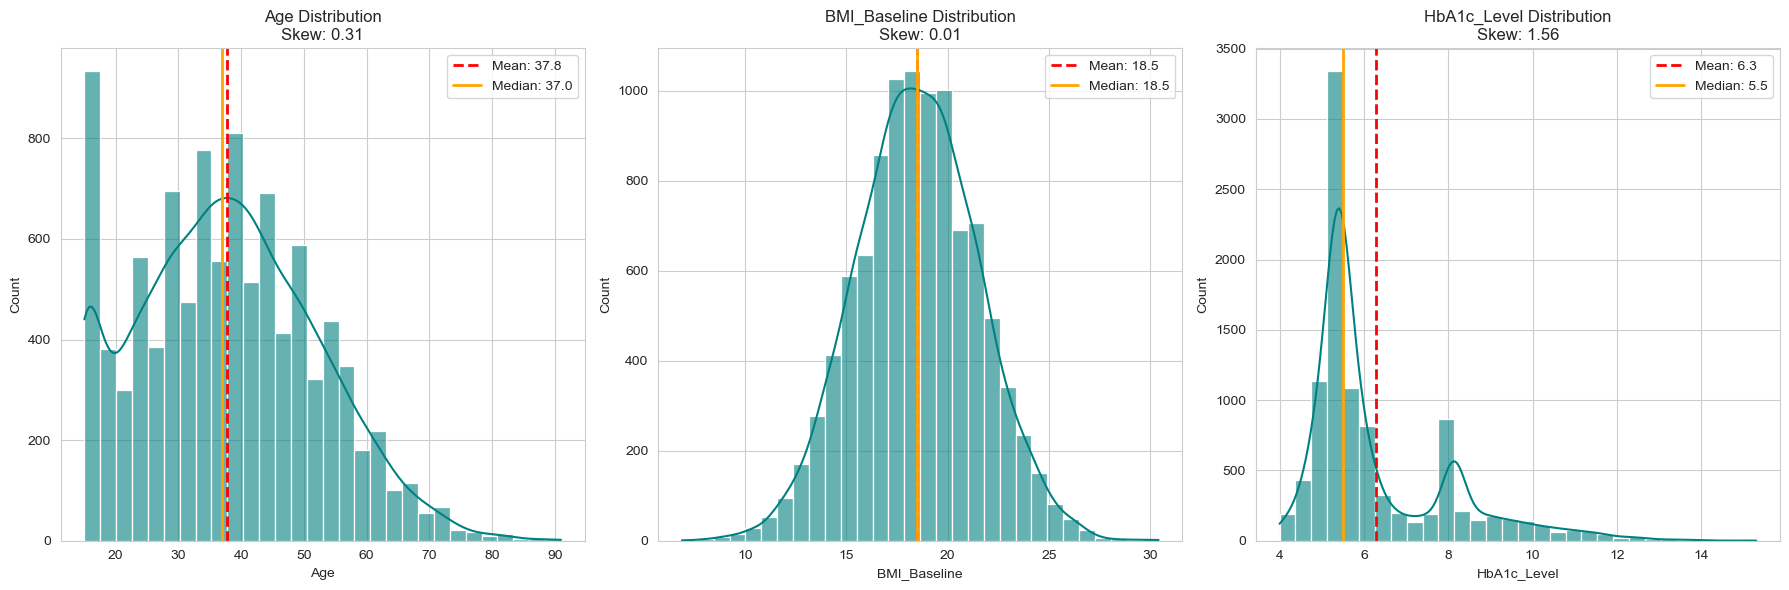

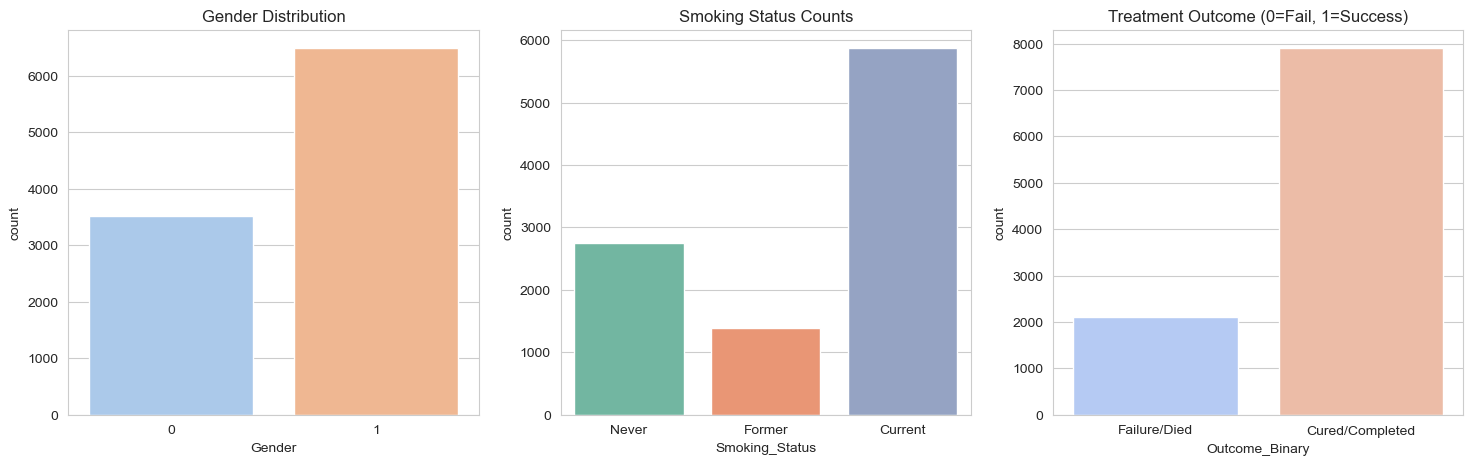

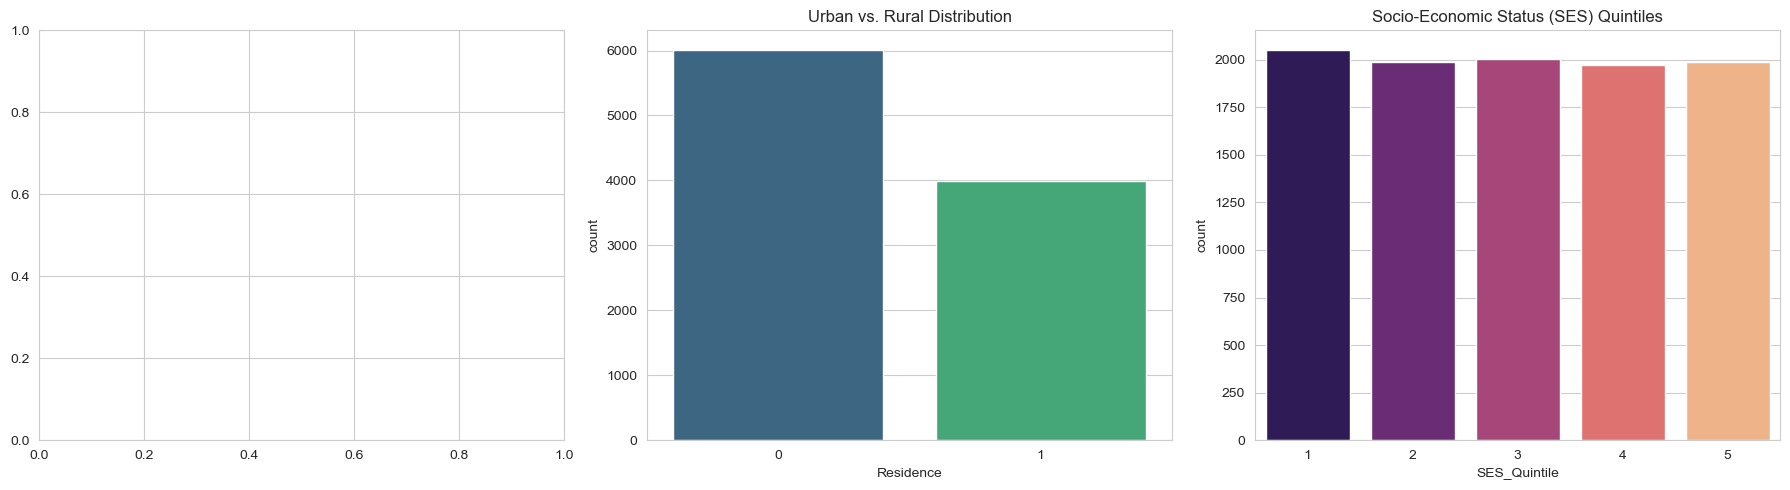

In [10]:
import scipy.stats as stats

# --- PART A: NUMERICAL DISTRIBUTIONS & SKEWNESS ---
numerical_cols = ['Age', 'BMI_Baseline', 'HbA1c_Level']
skew_vals = df[numerical_cols].skew()

print("--- Skewness Report ---")
print(skew_vals)
print("\n(Note: Skew > 1.0 indicates significant asymmetry)")

plt.figure(figsize=(18, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    
    # Histogram with KDE (Kernel Density Estimate)
    sns.histplot(df[col], kde=True, color='teal', bins=30, alpha=0.6)
    
    # Add Mean & Median lines to visualize skew
    plt.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df[col].mean():.1f}")
    plt.axvline(df[col].median(), color='orange', linestyle='-', linewidth=2, label=f"Median: {df[col].median():.1f}")
    
    plt.title(f'{col} Distribution\nSkew: {skew_vals[col]:.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

# --- PART B: CATEGORICAL COUNTS (UNIVARIATE) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gender Split
sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Gender Distribution')

# 2. Smoking Status
sns.countplot(x='Smoking_Status', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Smoking Status Counts')
axes[1].set_xticklabels(['Never', 'Former', 'Current'])

# 3. Target Variable Balance
sns.countplot(x='Outcome_Binary', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Treatment Outcome (0=Fail, 1=Success)')
axes[2].set_xticklabels(['Failure/Died', 'Cured/Completed'])

# Updated Part B to match your text:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gender Split
#sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')
#axes[0].set_title('Gender Distribution')

# 2. Residence Split (Matches Text)
sns.countplot(x='Residence', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Urban vs. Rural Distribution')

# 3. SES Quintile (Matches Text)
sns.countplot(x='SES_Quintile', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Socio-Economic Status (SES) Quintiles')

plt.tight_layout()
plt.show()

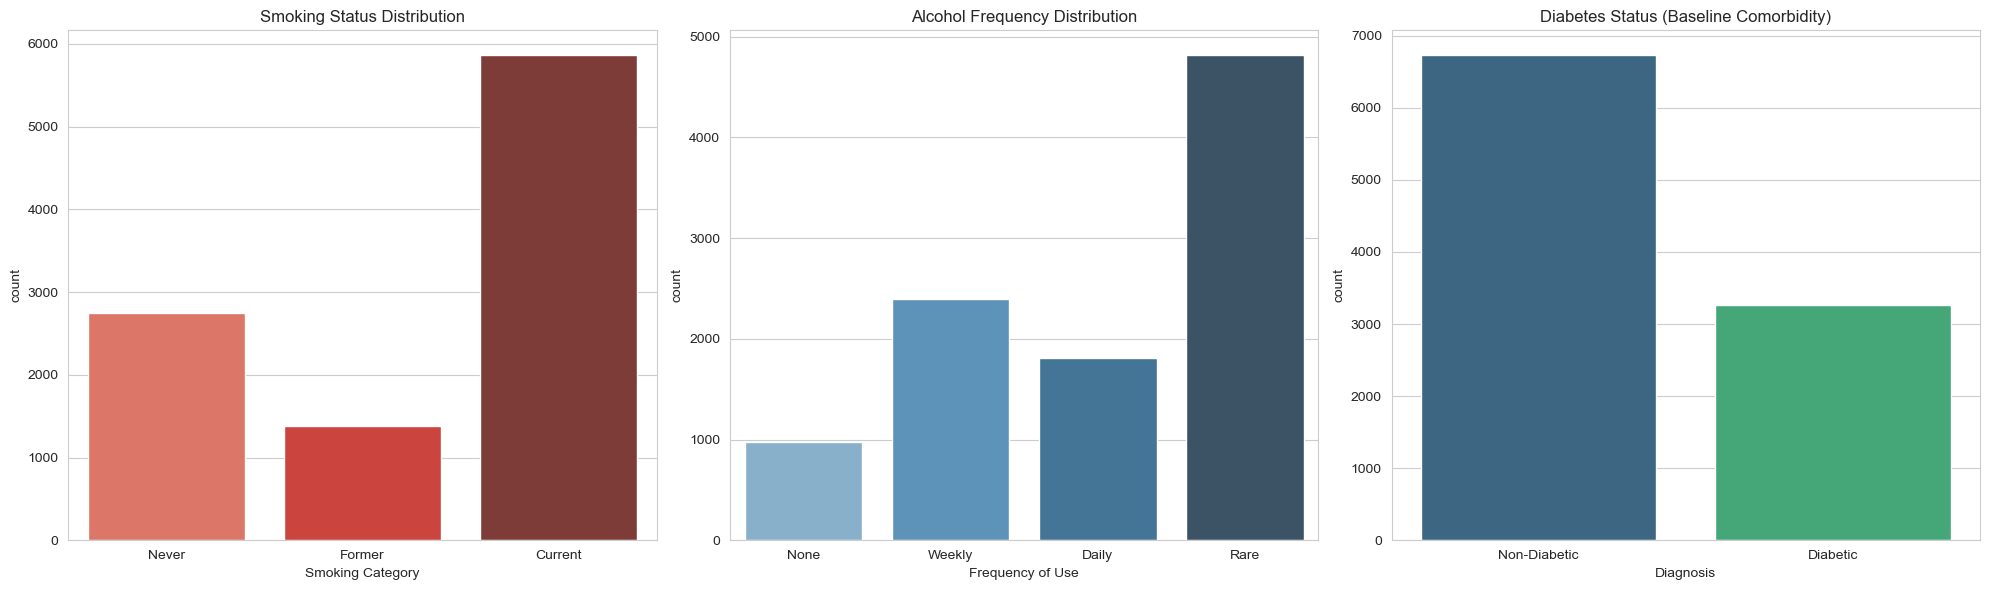

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PART C: LIFESTYLE & COMORBIDITY ANALYSIS ---
# This matches section 3.4.3 of your methodology
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fig 3.4: Smoking Status Distribution
sns.countplot(x='Smoking_Status', data=df, ax=axes[0], palette='Reds_d')
axes[0].set_title('Smoking Status Distribution')
axes[0].set_xticklabels(['Never', 'Former', 'Current'])
axes[0].set_xlabel('Smoking Category')

# 2. Fig 3.5: Alcohol Frequency Distribution
sns.countplot(x='Alcohol_Frequency', data=df, ax=axes[1], palette='Blues_d')
axes[1].set_title('Alcohol Frequency Distribution')
# Adjusting labels based on typical encoding (None=0, Weekly=1, Daily=2)
axes[1].set_xticklabels(['None', 'Weekly', 'Daily', 'Rare']) 
axes[1].set_xlabel('Frequency of Use')

# 3. Diabetes Status (Binary Distribution)
sns.countplot(x='Diabetes_Status', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Diabetes Status (Baseline Comorbidity)')
axes[2].set_xticklabels(['Non-Diabetic', 'Diabetic'])
axes[2].set_xlabel('Diagnosis')



plt.tight_layout()
plt.show()

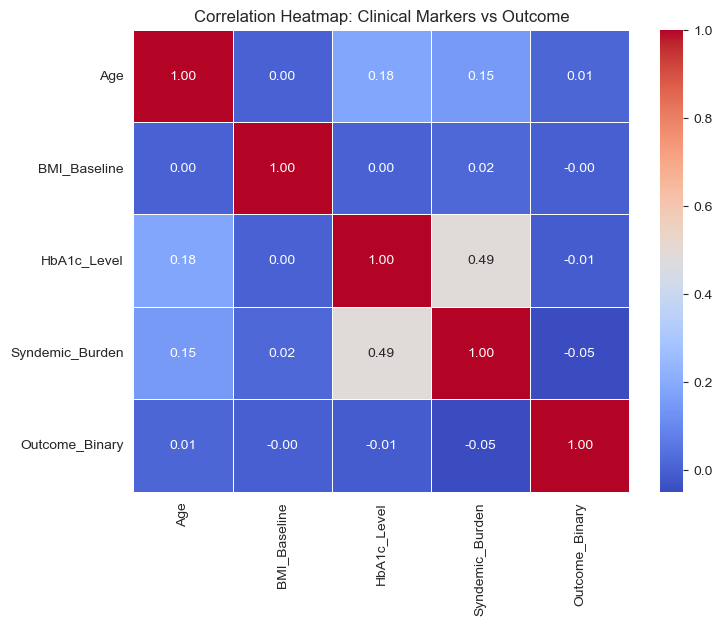

In [14]:
corr_cols = ['Age', 'BMI_Baseline', 'HbA1c_Level', 'Syndemic_Burden', 'Outcome_Binary']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Clinical Markers vs Outcome")
plt.show()

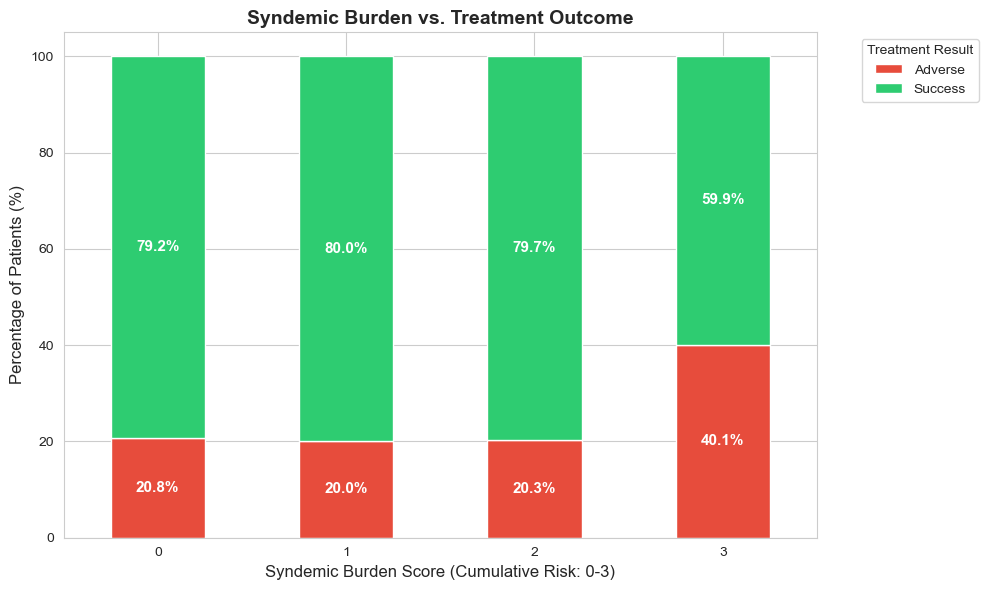

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('TB.csv')

# --- 1. CALCULATE SYNDEMIC BURDEN SCORE (0-3) ---
# A. Smoking Score: 1 point if they are a 'Current' or 'Former' smoker
df['Smoking_Score'] = df['Smoking_Status'].apply(lambda x: 1 if x in ['Current', 'Former'] else 0)

# B. Alcohol Score: 1 point if they drink 'Weekly' or 'Daily'
df['Alcohol_Score'] = df['Alcohol_Frequency'].apply(lambda x: 1 if x in ['Weekly', 'Daily'] else 0)

# C. Total Burden: Sum of Diabetes (already 0/1) + Smoking + Alcohol
df['Syndemic_Burden'] = df['Diabetes_Status'] + df['Smoking_Score'] + df['Alcohol_Score']

# --- 2. DEFINE OUTCOME LABELS ---
# Group outcomes into 'Success' vs 'Adverse' for the stacked bar chart
success_outcomes = ['Cured', 'Completed']
df['Outcome_Label'] = df['Treatment_Outcome'].apply(lambda x: 'Success' if x in success_outcomes else 'Adverse')

# --- 3. PREPARE DATA FOR PLOTTING ---
# Create a crosstab that shows the percentage of Success/Adverse for each Score (0, 1, 2, 3)
ct = pd.crosstab(df['Syndemic_Burden'], df['Outcome_Label'], normalize='index') * 100

# Ensure 'Adverse' is the bottom bar (Red) and 'Success' is the top bar (Green)
ct = ct[['Adverse', 'Success']]

# --- 4. GENERATE THE CHART ---
# Plot a Stacked Bar Chart
ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])

# Customize labels and titles
plt.title('Syndemic Burden vs. Treatment Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Syndemic Burden Score (Cumulative Risk: 0-3)', fontsize=12)
plt.ylabel('Percentage of Patients (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Treatment Result', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage text labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Only add label if bar has height
        ax.text(x+width/2, 
                y+height/2, 
                '{:.1f}%'.format(height), 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

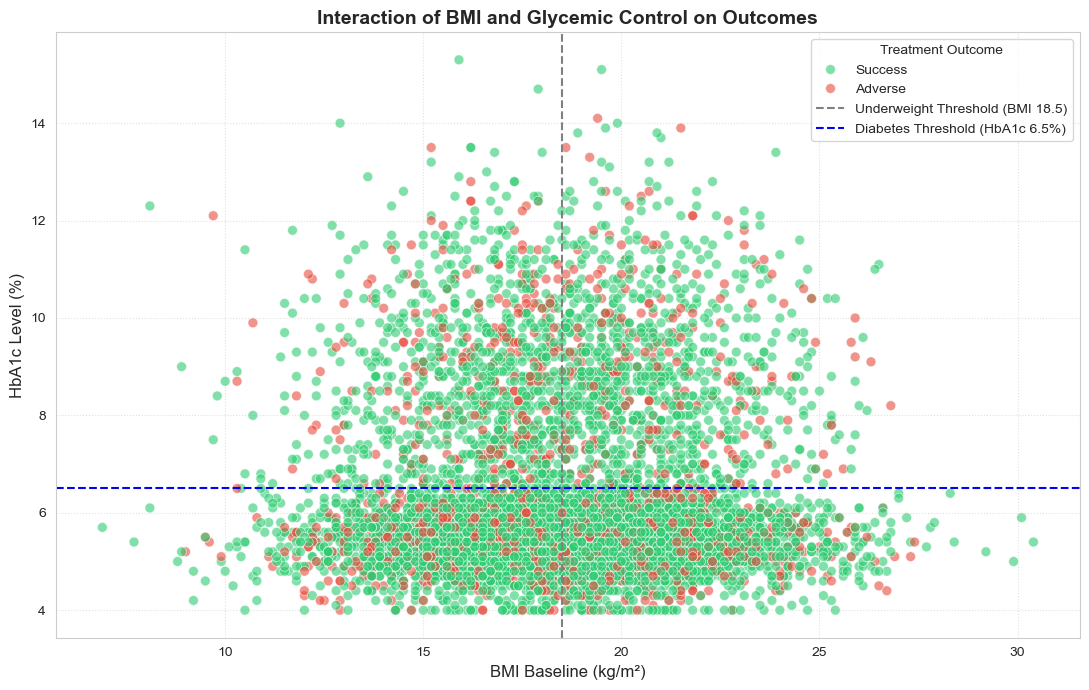

In [20]:
# --- PREPROCESSING ---
# 1. Create Binary Outcome for Coloring (Red vs Green)
success_outcomes = ['Cured', 'Completed']
df['Outcome_Label'] = df['Treatment_Outcome'].apply(lambda x: 'Success' if x in success_outcomes else 'Adverse')

# --- PLOTTING ---
plt.figure(figsize=(11, 7))

# Create the Scatter Plot
# x=BMI, y=HbA1c, hue=Outcome (Color)
sns.scatterplot(
    data=df, 
    x='BMI_Baseline', 
    y='HbA1c_Level', 
    hue='Outcome_Label', 
    palette={'Success': '#2ecc71', 'Adverse': '#e74c3c'}, # Green for Good, Red for Bad
    alpha=0.6,  # Transparency helps see overlapping points
    s=50        # Size of dots
)

# --- ADDING REFERENCE LINES (CLINICAL THRESHOLDS) ---
# 1. BMI Threshold for Underweight (<18.5)
plt.axvline(x=18.5, color='gray', linestyle='--', linewidth=1.5, label='Underweight Threshold (BMI 18.5)')

# 2. HbA1c Threshold for Diabetes (>6.5)
plt.axhline(y=6.5, color='blue', linestyle='--', linewidth=1.5, label='Diabetes Threshold (HbA1c 6.5%)')

# --- FORMATTING ---
plt.title('Interaction of BMI and Glycemic Control on Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('BMI Baseline (kg/m²)', fontsize=12)
plt.ylabel('HbA1c Level (%)', fontsize=12)
plt.legend(title='Treatment Outcome', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check Imbalance
outcome_counts = y_train.value_counts(normalize=True)
print("Original Class Distribution:\n", outcome_counts)

# Apply SMOTE if minority class < 40%
if outcome_counts.min() < 0.4:
    print("\n⚠️ Class Imbalance Detected. Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    print("New Class Distribution:\n", y_train_bal.value_counts(normalize=True))
else:
    X_train_bal, y_train_bal = X_train, y_train
    print("Classes are balanced. SMOTE not required.")

Original Class Distribution:
 Outcome_Binary
1    0.788375
0    0.211625
Name: proportion, dtype: float64

⚠️ Class Imbalance Detected. Applying SMOTE...
New Class Distribution:
 Outcome_Binary
1    0.5
0    0.5
Name: proportion, dtype: float64


In [7]:
## new


2. Training & Evaluating Models...


✅ Logistic Regression: Accuracy = 0.7960
✅ Random Forest: Accuracy = 0.7670
✅ AdaBoost: Accuracy = 0.8005
✅ Gradient Boosting: Accuracy = 0.7870
✅ SVM (RBF Kernel): Accuracy = 0.7960


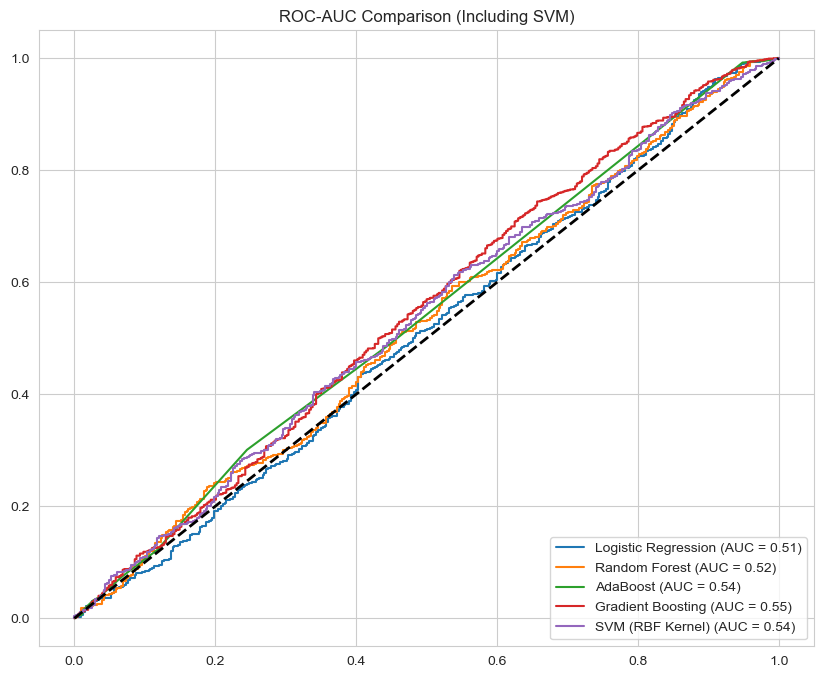


3. Generating Individual Analysis for Each Model...

==================== LOGISTIC REGRESSION ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       408
           1       0.80      1.00      0.89      1592

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



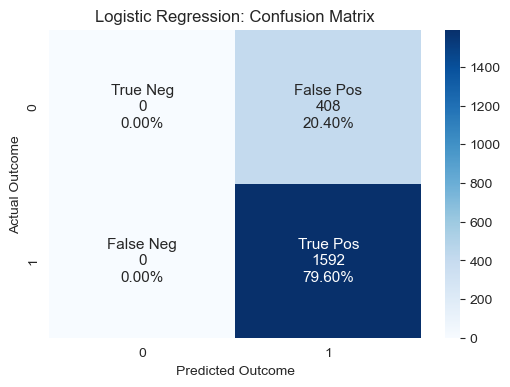




==================== RANDOM FOREST ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.09      0.13       408
           1       0.80      0.94      0.87      1592

    accuracy                           0.77      2000
   macro avg       0.54      0.51      0.50      2000
weighted avg       0.69      0.77      0.72      2000



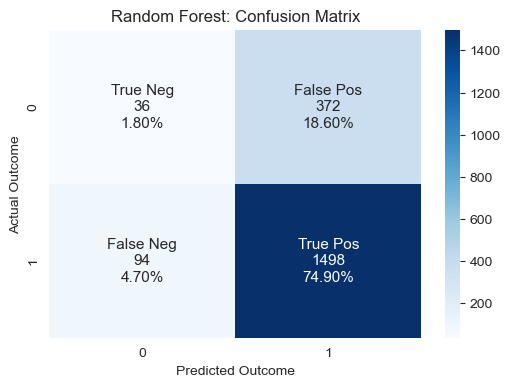




==================== ADABOOST ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.05      0.10       408
           1       0.80      0.99      0.89      1592

    accuracy                           0.80      2000
   macro avg       0.72      0.52      0.49      2000
weighted avg       0.77      0.80      0.73      2000



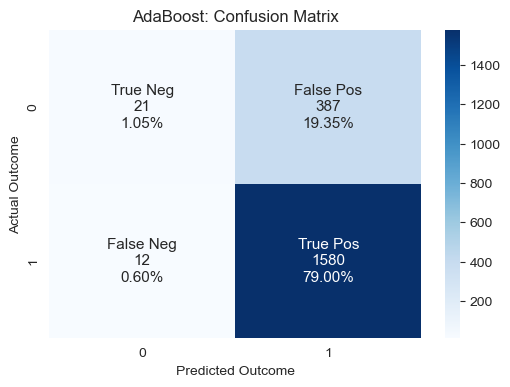




==================== GRADIENT BOOSTING ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.07      0.12       408
           1       0.80      0.97      0.88      1592

    accuracy                           0.79      2000
   macro avg       0.59      0.52      0.50      2000
weighted avg       0.72      0.79      0.72      2000



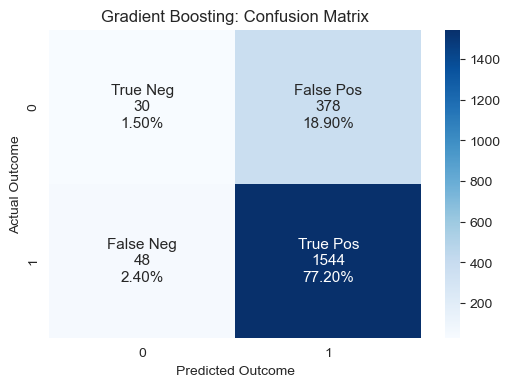




==================== SVM (RBF KERNEL) ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       408
           1       0.80      1.00      0.89      1592

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



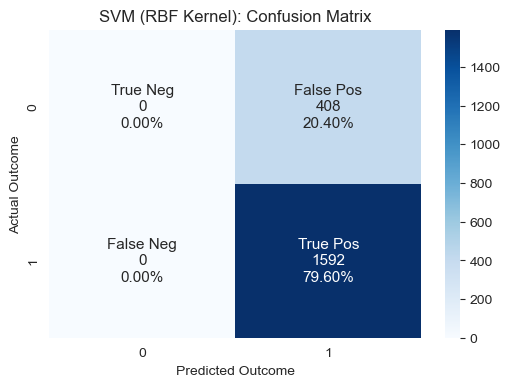



🏆 SUMMARY: AdaBoost is the best performer.


['best_tb_model.pkl']

In [8]:
import joblib
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=0.5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=15, class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

# Storage
model_results = {}
confusion_matrices = {}
reports = {} # New storage for reports
best_acc = 0.0
best_model_name = ""
best_model_obj = None

# --- STEP 3: TRAIN & EVALUATE ---
print("\n2. Training & Evaluating Models...")
plt.figure(figsize=(10, 8)) 

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    reports[name] = classification_report(y_test, y_pred) # Generate Report
    
    # Save Best
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model_obj = model
    
    # Plot ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    print(f"✅ {name}: Accuracy = {acc:.4f}")

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC-AUC Comparison (Including SVM)')
plt.legend(loc="lower right")
plt.show()

# --- STEP 4: DETAILED VISUALIZATION & REPORTS ---
print("\n3. Generating Individual Analysis for Each Model...")

for name in models.keys():
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    
    # A. Show Classification Report
    print("Classification Report:")
    print(reports[name])
    
    # B. Plot Confusion Matrix
    cm = confusion_matrices[name]
    plt.figure(figsize=(6, 4))
    
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', annot_kws={"size": 11})
    plt.title(f"{name}: Confusion Matrix")
    plt.xlabel("Predicted Outcome")
    plt.ylabel("Actual Outcome")
    plt.show()
    print("\n")

# Save Best
print(f"🏆 SUMMARY: {best_model_name} is the best performer.")
joblib.dump(best_model_obj, 'best_tb_model.pkl')